In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

/content


In [ ]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize']= (8,5)

In [ ]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
df = pd.read_csv("Morning_Routine_Productivity_Dataset.csv")
df.head()

Current working directory: /content
Files in current directory: ['.config', 'Morning_Routine_Productivity_Dataset.csv', 'sample_data']


,Date,Wake-up Time,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Breakfast Type,Journaling (Y/N),Work Start Time,Productivity_Score (1-10),Mood,Notes
0,21:52.9,5:30 AM,6.6,20,60,Protein-rich,Yes,6:30 AM,6,Neutral,Collection whole decision middle.
1,21:52.9,8:15 AM,8.0,5,50,Heavy,No,11:15 AM,7,Happy,Tree player behavior various up such attention...
2,21:52.9,8:30 AM,8.9,25,30,Carb-rich,Yes,10:30 AM,10,Happy,If hard focus nor trip forward change per.
3,21:52.9,5:00 AM,8.4,25,30,Skipped,Yes,7:00 AM,7,Happy,Physical threat federal with thing.
4,21:52.9,5:15 AM,8.2,25,30,Heavy,No,6:15 AM,10,Happy,Ground class Mr future.


In [ ]:
#eksplorasi awal
print("\informasi dataset:")
display(df.info())

print("\jumlah missing value per kolom: ")
display(df.isnull().sum())

\informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       900 non-null    object 
 1   Wake-up Time               900 non-null    object 
 2   Sleep Duration (hrs)       900 non-null    float64
 3   Meditation (mins)          900 non-null    int64  
 4   Exercise (mins)            900 non-null    int64  
 5   Breakfast Type             900 non-null    object 
 6   Journaling (Y/N)           900 non-null    object 
 7   Work Start Time            900 non-null    object 
 8   Productivity_Score (1-10)  900 non-null    int64  
 9   Mood                       900 non-null    object 
 10  Notes                      900 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 77.5+ KB


<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\j'
<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\j'
/tmp/ipython-input-3204401352.py:2: SyntaxWarning: invalid escape sequence '\i'
  print("\informasi dataset:")
/tmp/ipython-input-3204401352.py:5: SyntaxWarning: invalid escape sequence '\j'
  print("\jumlah missing value per kolom: ")


None

\jumlah missing value per kolom: 


,0
Date,0
Wake-up Time,0
Sleep Duration (hrs),0
Meditation (mins),0
Exercise (mins),0
Breakfast Type,0
Journaling (Y/N),0
Work Start Time,0
Productivity_Score (1-10),0
Mood,0


In [ ]:
df.describe()

,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Productivity_Score (1-10)
count,900.000000,900.000000,900.000000,900.000000
mean,6.978444,14.711111,29.733333,5.811111
std,1.149872,9.937227,20.622568,2.157814
min,5.000000,0.000000,0.000000,1.000000
25%,5.900000,5.000000,10.000000,4.000000
50%,7.000000,15.000000,30.000000,6.000000
75%,8.000000,25.000000,50.000000,7.000000
max,9.000000,30.000000,60.000000,10.000000


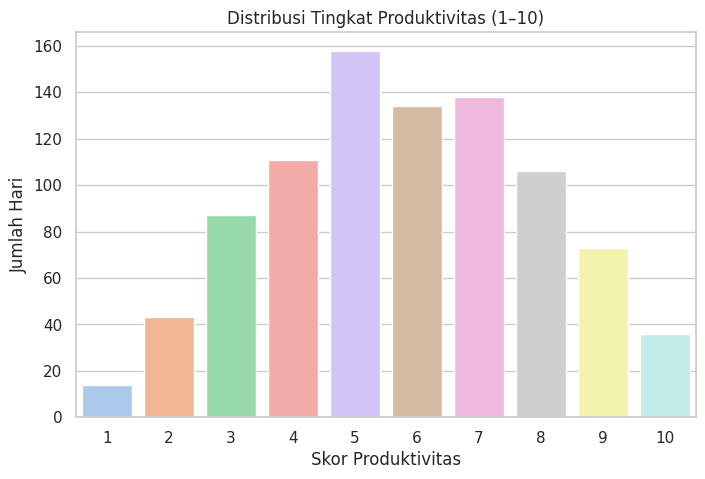

In [ ]:
import warnings

# 1. Abaikan warning
warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Load dataset
df = pd.read_csv("Morning_Routine_Productivity_Dataset.csv")

# 3. Visualisasi distribusi target variabel
sns.countplot(
    x="Productivity_Score (1-10)",  # Mengubah nama kolom menjadi yang benar
    data=df,
    palette="pastel"
)
plt.title("Distribusi Tingkat Produktivitas (1–10)")
plt.xlabel("Skor Produktivitas")
plt.ylabel("Jumlah Hari")
plt.show()

In [ ]:
df['Productivity_Score (1-10)'].value_counts()

,count
Productivity_Score (1-10),
5,158
7,138
6,134
4,111
8,106
3,87
9,73
2,43
10,36


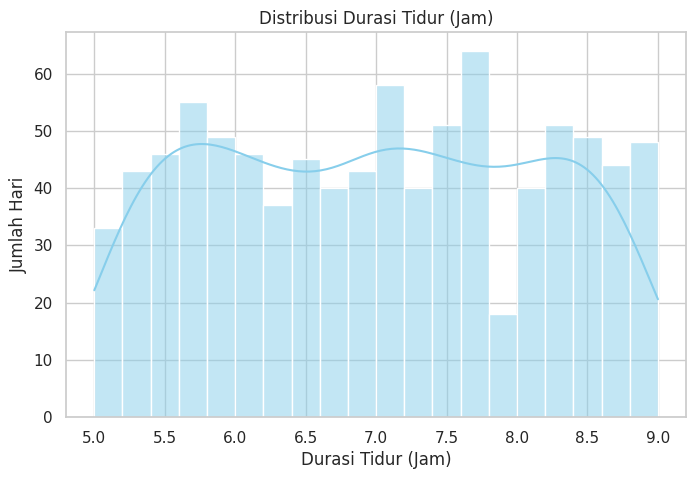

In [ ]:
sns.histplot(df["Sleep Duration (hrs)"].dropna(), bins=20, kde=True, color="skyblue")
plt.title("Distribusi Durasi Tidur (Jam)")
plt.xlabel("Durasi Tidur (Jam)")
plt.ylabel("Jumlah Hari")
plt.show()


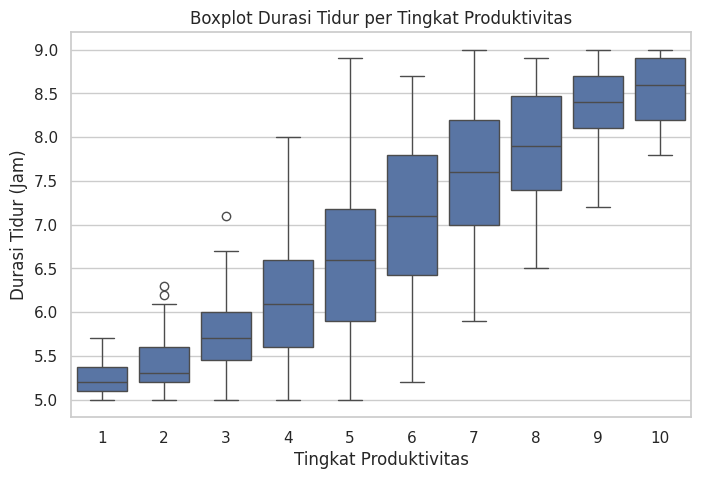

In [ ]:
sns.boxplot(
    x="Productivity_Score (1-10)", # Mengubah nama kolom menjadi yang benar
    y="Sleep Duration (hrs)",
    data=df
)
plt.title("Boxplot Durasi Tidur per Tingkat Produktivitas")
plt.xlabel("Tingkat Produktivitas")
plt.ylabel("Durasi Tidur (Jam)")
plt.show()

In [ ]:
df["Productivity_Score (1-10)"].head()
print(df["Productivity_Score (1-10)"].dtype)

int64


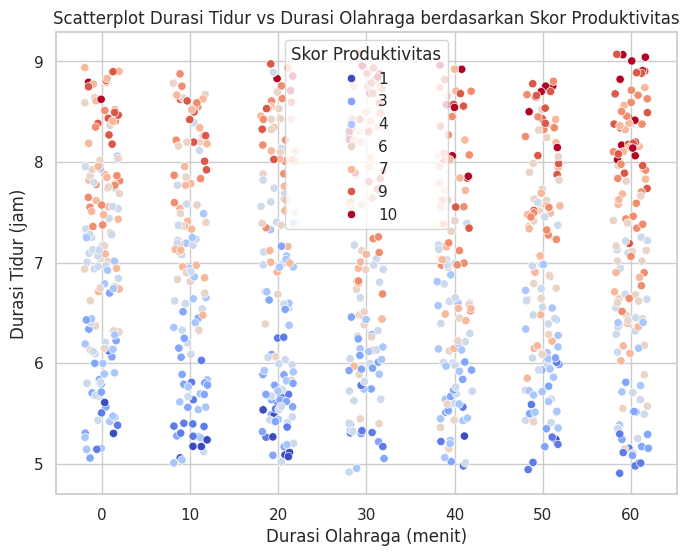

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# tambahkan jitter ke data (acak kecil biar nyebar)
x_jitter = df["Exercise (mins)"] + np.random.uniform(-2, 2, size=len(df))
y_jitter = df["Sleep Duration (hrs)"] + np.random.uniform(-0.1, 0.1, size=len(df))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=x_jitter,
    y=y_jitter,
    hue=df["Productivity_Score (1-10)"], # Corrected column name
    palette="coolwarm"
)
plt.title("Scatterplot Durasi Tidur vs Durasi Olahraga berdasarkan Skor Produktivitas")
plt.xlabel("Durasi Olahraga (menit)")
plt.ylabel("Durasi Tidur (jam)")
plt.legend(title="Skor Produktivitas")
plt.show()

Kolom numerik yang ditemukan:
['Sleep Duration (hrs)', 'Meditation (mins)', 'Exercise (mins)', 'Productivity_Score (1-10)']


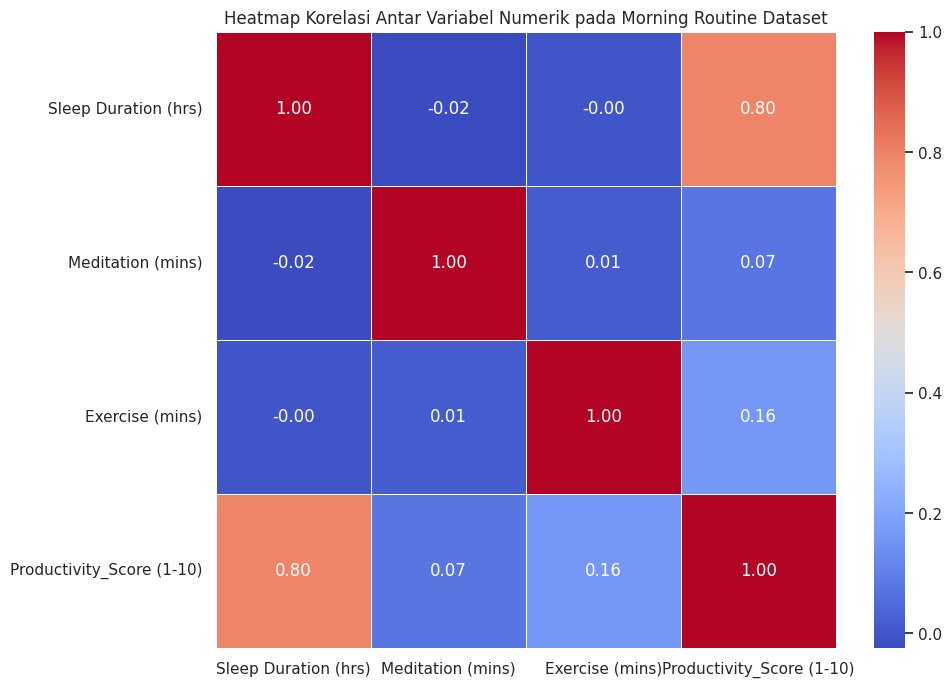

In [ ]:

# --- 2️⃣ Pilih hanya kolom numerik ---
numeric_df = df.select_dtypes(include=np.number)

# --- 3️⃣ Cek apakah ada kolom numerik ---
print("Kolom numerik yang ditemukan:")
print(numeric_df.columns.tolist())

# --- 4️⃣ Heatmap korelasi ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,        # menampilkan nilai korelasi di dalam sel
    cmap="coolwarm",   # skema warna
    fmt=".2f",         # format angka 2 desimal
    linewidths=0.5
)
plt.title("Heatmap Korelasi Antar Variabel Numerik pada Morning Routine Dataset")
plt.show()


In [ ]:


# --- a) Imputasi Missing Values ---
# Ganti nilai kosong pada kolom numerik dengan median
df["Sleep Duration (hrs)"] = df["Sleep Duration (hrs)"].fillna(df["Sleep Duration (hrs)"].median())
df["Meditation (mins)"] = df["Meditation (mins)"].fillna(df["Meditation (mins)"].median())
df["Exercise (mins)"] = df["Exercise (mins)"].fillna(df["Exercise (mins)"].median())

# Untuk kolom kategorikal, isi dengan modus
df["Breakfast Type"] = df["Breakfast Type"].fillna(df["Breakfast Type"].mode()[0])
df["Journaling (Y/N)"] = df["Journaling (Y/N)"].fillna(df["Journaling (Y/N)"].mode()[0])
df["Mood"] = df["Mood"].fillna(df["Mood"].mode()[0])

# --- b) Fitur Baru ---
# Buat kategori produktivitas
df["Productivity_Level"] = df["Productivity_Score (1-10)"].apply(
    lambda x: "Produktif" if x >= 7 else "Tidak Produktif"
)

# Buat kolom “Healthy Morning” berdasarkan kombinasi perilaku baik
df["Healthy_Morning"] = np.where(
    (df["Sleep Duration (hrs)"] >= 7) &
    (df["Meditation (mins)"] >= 10) &
    (df["Exercise (mins)"] >= 30) &
    (df["Breakfast Type"] != "Skipped") &
    (df["Journaling (Y/N)"] == "Yes"),
    "Yes", "No"
)

# --- c) Binning Durasi Tidur ---
df["Sleep_Category"] = pd.cut(
    df["Sleep Duration (hrs)"],
    bins=[0, 5, 7, 9, 12],
    labels=["Kurang Tidur", "Cukup Tidur", "Ideal", "Berlebihan"]
)

# --- d) Tampilkan hasil akhir ---
print(df.head())

      Date Wake-up Time  Sleep Duration (hrs)  Meditation (mins)  \
0  21:52.9      5:30 AM                   6.6                 20   
1  21:52.9      8:15 AM                   8.0                  5   
2  21:52.9      8:30 AM                   8.9                 25   
3  21:52.9      5:00 AM                   8.4                 25   
4  21:52.9      5:15 AM                   8.2                 25   

   Exercise (mins) Breakfast Type Journaling (Y/N) Work Start Time  \
0               60   Protein-rich              Yes         6:30 AM   
1               50          Heavy               No        11:15 AM   
2               30      Carb-rich              Yes        10:30 AM   
3               30        Skipped              Yes         7:00 AM   
4               30          Heavy               No         6:15 AM   

   Productivity_Score (1-10)     Mood  \
0                          6  Neutral   
1                          7    Happy   
2                         10    Happy   
3     

In [ ]:


# Encode variabel kategori jadi numerik
df_encoded = pd.get_dummies(df, columns=["Breakfast Type", "Journaling (Y/N)",
                                         "Mood"], drop_first=True)

# Pilih kolom yang relevan untuk analisis produktivitas
drop_cols = ["Date", "Wake-up Time", "Work Start Time", "Notes"]
df_final = df_encoded.drop(drop_cols, axis=1)

print("\nDataset setelah feature engineering & selection:")
display(df_final.head())



Dataset setelah feature engineering & selection:


,Sleep Duration (hrs),Meditation (mins),Exercise (mins),Productivity_Score (1-10),Productivity_Level,Healthy_Morning,Sleep_Category,Breakfast Type_Heavy,Breakfast Type_Light,Breakfast Type_Protein-rich,Breakfast Type_Skipped,Journaling (Y/N)_Yes,Mood_Neutral,Mood_Sad
0,6.6,20,60,6,Tidak Produktif,No,Cukup Tidur,False,False,True,False,True,True,False
1,8.0,5,50,7,Produktif,No,Ideal,True,False,False,False,False,False,False
2,8.9,25,30,10,Produktif,Yes,Ideal,False,False,False,False,True,False,False
3,8.4,25,30,7,Produktif,No,Ideal,False,False,False,True,True,False,False
4,8.2,25,30,10,Produktif,No,Ideal,True,False,False,False,False,False,False


In [ ]:
# ============================================================
# 13. Split Data
# ============================================================
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = df_final.drop("Productivity_Score (1-10)", axis=1)
y = df_final["Productivity_Score (1-10)"]

# Bagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Cek jumlah data
print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji:", X_test.shape[0])

Jumlah data latih: 720
Jumlah data uji: 180


In [ ]:


# Baca file dataset kamu
df = pd.read_csv("Morning_Routine_Productivity_Dataset.csv")

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=["Productivity_Score (1-10)"])
y = df["Productivity_Score (1-10)"]

# Bagi dataset: 80% train, 20% sisa (untuk test + validasi)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Bagi lagi sisa 20% menjadi 10% validasi dan 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Tampilkan jumlah data tiap set
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))


Jumlah data latih: 720
Jumlah data validasi: 90
Jumlah data uji: 90


In [23]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, f1_score, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

import lightgbm as lgb

# ==========================
# 1. Load dataset
# ==========================
df = pd.read_csv("Morning_Routine_Productivity_Dataset.csv")

# Encode variabel kategori
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ==========================
# 2. Supervised Learning - Klasifikasi
# Target: Produktif / Tidak Produktif
# ==========================
df["Produktif"] = (df["Productivity_Score (1-10)"] >= 7).astype(int)

X = df.drop(columns=["Productivity_Score (1-10)", "Produktif"])
y = df["Produktif"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ==========================
# 3. Supervised Learning - Regresi
# Prediksi: Productivity Score (1-10)
# ==========================
X_reg = df.drop(columns=["Productivity_Score (1-10)", "Produktif"])
y_reg = df["Productivity_Score (1-10)"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# --- Linear Regression ---
reg = LinearRegression()
reg.fit(X_train, y_train)
y_val_pred_lin = reg.predict(X_val)
mse_lin = mean_squared_error(y_val, y_val_pred_lin)

print("\n=== Regresi: Linear Regression ===")
print("MSE validasi:", mse_lin)



=== Regresi: Linear Regression ===
MSE validasi: 1.1829627352797953


In [20]:
import pandas as pd


In [22]:
pd.show_versions(as_json=False)


INSTALLED VERSIONS
------------------
commit                : d9cdd2ee5a58015ef6f4d15c7226110c9aab8140
python                : 3.12.12.final.0
python-bits           : 64
OS                    : Linux
OS-release            : 6.6.105+
Version               : #1 SMP Thu Oct  2 10:42:05 UTC 2025
machine               : x86_64
processor             : x86_64
byteorder             : little
LC_ALL                : en_US.UTF-8
LANG                  : en_US.UTF-8
LOCALE                : en_US.UTF-8

pandas                : 2.2.2
numpy                 : 2.0.2
pytz                  : 2025.2
dateutil              : 2.9.0.post0
setuptools            : 75.2.0
pip                   : 24.1.2
Cython                : 3.0.12
pytest                : 8.4.2
hypothesis            : None
sphinx                : 8.2.3
blosc                 : None
feather               : None
xlsxwriter            : None
lxml.etree            : 6.0.2
html5lib              : 1.1
pymysql               : None
psycopg2             